In [17]:
pip install yfinance

Note: you may need to restart the kernel to use updated packages.


In [18]:
# Import libraries
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy import stats
from scipy.optimize import minimize
from statsmodels.stats.diagnostic import normal_ad
from scipy.stats import skew, kurtosis, chi2
from datetime import date, datetime, timedelta


# Project Introduction: Asset Allocation and Portfolio Construction

In this project, we will construct a **strategic investment portfolio** using historical market data. The portfolio is built from a selection of **diversified asset classes** to balance risk and return across different economic sectors and geographies.

We use historical price data from **Yahoo Finance** for the following ETFs and indices:

- **SPY** – U.S. Equities (S&P 500 Index)
- **QQQ** – Nasdaq-100 ( focused on Growth Stocks / Technology-sector)
- **^GDAXI** – German Stocks (DAX Index)
- **VNQ** – Real Estate Investment Trusts (REITs)
- **TLT** – Long-term U.S. Government Bonds
- **GLD** – Gold

---

### Objective

Our goal is to identify an **optimal portfolio allocation** based on modern portfolio theory. We analyze the portfolio using **statistical and econometric tools** like statistical testing, OLS-regression and optimization.

---

### Methodological Steps

1. **Data Processing & Jarque-Bera Normality Test**  
   &nbsp;&nbsp;&nbsp;&nbsp;• Fetch and clean asset price data  
   &nbsp;&nbsp;&nbsp;&nbsp;• Calculate log-returns  
   &nbsp;&nbsp;&nbsp;&nbsp;• Test for normality of returns using the Jarque-Bera test

2. **Investment Opportunity Set & Efficient Frontier**  
   &nbsp;&nbsp;&nbsp;&nbsp;• Estimate expected returns and covariance matrix  
   &nbsp;&nbsp;&nbsp;&nbsp;• Construct the mean-variance efficient frontier  
   &nbsp;&nbsp;&nbsp;&nbsp;• Visualize individual asset risk-return profiles

3. **Tangency Portfolio vs. Optimal Complete Portfolio**  
   &nbsp;&nbsp;&nbsp;&nbsp;• Calculation of the tangency portfolio that maximizes the Sharpe Ratio  
   &nbsp;&nbsp;&nbsp;&nbsp;• Determine the investor-specific optimal allocation using risk aversion

4. **Risk Decomposition via OLS Regression**  
   &nbsp;&nbsp;&nbsp;&nbsp;• Decompose portfolio return into:  
   &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;– **Systematic Return (β)**  
   &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;– **Idiosyncratic Return (α)**  
   &nbsp;&nbsp;&nbsp;&nbsp;• Analyze corresponding risk components

5. **Expected vs. Realized Performance**  
   &nbsp;&nbsp;&nbsp;&nbsp;• Evaluate performance on test data  
   &nbsp;&nbsp;&nbsp;&nbsp;• Compare expected return/volatility with realized out-of-sample results

---

Our project offers a complete, data-driven exploration of **modern portfolio construction**.


In [19]:
# 1. Data Acquisition
def fetch_asset_data(tickers, start_date, end_date):
    """Fetch price data from Yahoo Finance with fallback to 'Close' and full MultiIndex support."""
    
    data = yf.download(tickers, start=start_date, end=end_date, progress=False)

    if "Adj Close" in [column[0] for column in data.columns]:
        adj_close = data['Adj Close']
    else:
        adj_close = data["Close"]

    # Clean data
    adj_close.columns = [col.replace('.', '_') for col in adj_close.columns]
    adj_close = adj_close.dropna()

    return adj_close


#tickers = sorted(['NFLX', 'TSLA', 'HD', 'KO', 'COST', 'MU'])
tickers = sorted(["SPY", "GLD", "VNQ", "TLT", "QQQ", "^GDAXI"])
tickers2 = sorted(['SPY']) # for benchmarking
start_date = '2010-01-01' 
end_date = '2024-12-31'

#start_date = '2008-01-01'
#end_date = '2022-12-31'

asset_prices = fetch_asset_data(tickers, start_date, end_date)
market_prices = fetch_asset_data(tickers2, start_date, end_date)


asset_prices.head(5)

,GLD,QQQ,SPY,TLT,VNQ,^GDAXI
Date,,,,,,
2010-01-04,109.800003,40.485802,85.768463,58.467255,24.488733,6048.299805
2010-01-05,109.699997,40.485802,85.995483,58.844818,24.461250,6031.859863
2010-01-06,111.510002,40.241604,86.056030,58.057159,24.417267,6034.330078
2010-01-07,110.820000,40.267761,86.419296,58.154793,24.681124,6019.359863
2010-01-08,111.370003,40.599197,86.706879,58.128742,24.499723,6037.609863


In [20]:
# Calculate daily returns
returns = asset_prices.pct_change().dropna()  
returns_market = market_prices.pct_change().dropna()
annualized_returns = returns.mean() * 252
annualized_volatility = returns.std() * np.sqrt(252)


print("Annualized Returns:")
print(annualized_returns)
print("\nAnnualized Volatility:")
print(annualized_volatility)

Annualized Returns:
GLD       0.065557
QQQ       0.194135
SPY       0.145440
TLT       0.038552
VNQ       0.108291
^GDAXI    0.100622
dtype: float64

Annualized Volatility:
GLD       0.156109
QQQ       0.205678
SPY       0.171260
TLT       0.154054
VNQ       0.207914
^GDAXI    0.197815
dtype: float64


### Visualization of our Asset Trajectories
#### Why Use Cumulated Log-Returns for visualization?

We use **log-returns** instead of simple returns or because they are:

- **Time additivity**: Log-returns are additive over time

- **Scale-visualization**: Many stocks grow exponentially — a log scale makes such trends appear linear and easier to interpret


The cumulated log-returns show the **relative performance** of each asset. 
Overall, this plot helps us to identify **return patterns and diversification potential** 


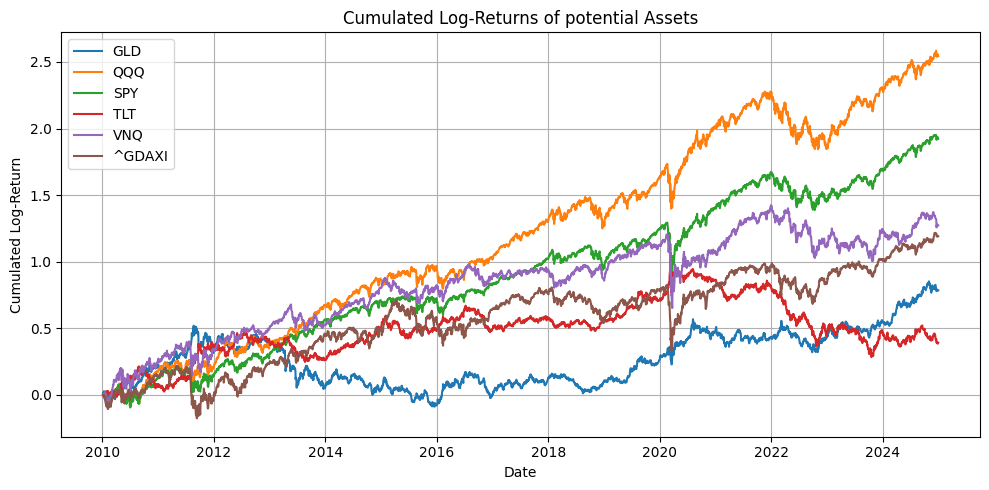

In [21]:

#calculate cumulated log-returns of the assets
log_returns = np.log(asset_prices / asset_prices.shift(1)).dropna()
cumulative_log_returns = log_returns.cumsum()

# Visualize
plt.figure(figsize=(10, 5))
for ticker in cumulative_log_returns.columns:
    plt.plot(cumulative_log_returns.index, cumulative_log_returns[ticker], label=ticker)

plt.title('Cumulated Log-Returns of potential Assets')
plt.xlabel('Date')
plt.ylabel('Cumulated Log-Return')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()



---
---
## 1) Testing for Normal Distribution: Jarque-Bera Test

The **Jarque-Bera test** checks if our data follows a **normal distribution** based on its **skewness** and **kurtosis**.

In finance, especially when using models like the **Capital Asset Pricing Model (CAPM)**, normality of returns is often assumed. This is important because many statistical methods (e.g. linear regression) are based on the idea that residuals or input variables behave "nicely" — meaning they’re symmetrically distributed without extreme outliers.

The Jarque-Bera test statistic is:

$$
JB = \frac{n}{6} \left( \text{Skewness}^2 + \frac{1}{4}(\text{Kurtosis} - 3)^2 \right)
$$

- **Skewness** tells us if the distribution is symmetric or lopsided  
- **Kurtosis** tells us how heavy the tails are (i.e. how likely extreme values are)

If the resulting **p-value is small (< 0.05)**, we reject the assumption of normality — which can be not good when wef apply CAPM to real data.

In [22]:
def test_normality(returns):
    """Perform Jarque-Bera test for normality on returns"""
    print("\nJarque-Beta Test for normal distribution:")
    results = {}

    for asset in returns.columns:
        data = returns[asset].dropna()
        n = len(data)
        
        skew_val = stats.skew(data)
        kurt_val = stats.kurtosis(data, fisher=False)  
        
        # JB-Test-Statistik
        jb_stat = (n / 6) * (skew_val**2 + ((kurt_val - 3)**2) / 4)
        p_value = 1 - chi2.cdf(jb_stat, df=2)
        
        # Dictionary to store statistical values
        results[asset] = {
            'JB Teststatistic': jb_stat,
            'p-value': p_value,
            'Skewness': skew_val,
            'Kurtosis': kurt_val,
            'is Normal Distr.?': 'Ja' if p_value > 0.05 else 'Nein'
        }
    
    return pd.DataFrame(results).T

normality_results = test_normality(returns)
normality_results


Jarque-Beta Test for normal distribution:


,JB Teststatistic,p-value,Skewness,Kurtosis,is Normal Distr.?
GLD,3033.90805,0.0,-0.399641,7.359288,Nein
QQQ,5582.366307,0.0,-0.356785,8.969287,Nein
SPY,17837.113769,0.0,-0.524936,13.694835,Nein
TLT,1840.519481,0.0,0.057178,6.450056,Nein
VNQ,38779.256328,0.0,-0.754631,18.773023,Nein
^GDAXI,7903.236202,0.0,-0.311418,10.125974,Nein


### Why our Asset Returns Are Not Normally Distributed

In theory, we want our financial returns to follow a normal distribution (clean, symmetric, and with strange outliers). But our example data, return distributions are usually not gaussian:

- They have **fat tails**, meaning extreme losses or gains happen more frequently than a normal model would estimate.
- Returns can be **skewed**, especially during crises or bubbles when the stock-market goes asymmetrically.
- Real events — shocks (z.B. Corona), panic selling, **black swans** — are **extreme events** that disprove the assumptions of normality.

That's why our assets fail the test. That doesn't mean we can't use CAPM — but it reminds us to  consider model limitations when interpreting results.




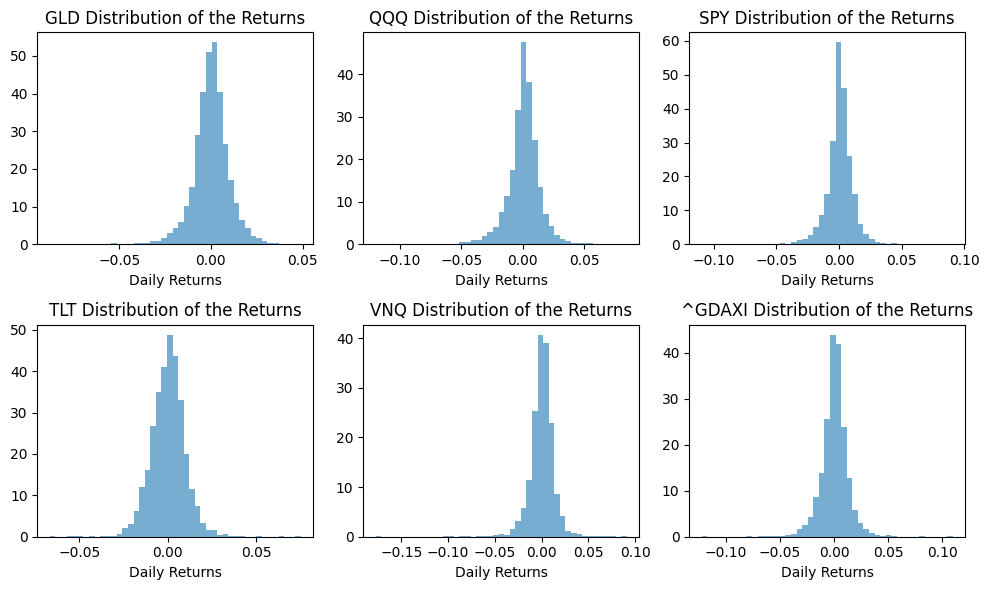

In [23]:
# Plot return distributions
fig, axes = plt.subplots(2, 3, figsize=(10, 6))
axes = axes.flatten()

for i, asset in enumerate(returns.columns):
    axes[i].hist(returns[asset], bins=45, density=True, alpha=0.6)
    axes[i].set_title(f'{asset} Distribution of the Returns')
    axes[i].set_xlabel('Daily Returns')
    
plt.tight_layout()
plt.show()

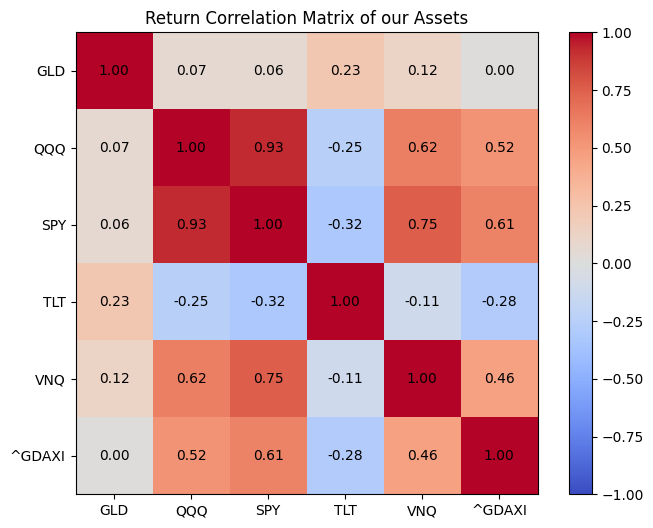

In [24]:
# Calculate correlation matrix and visualisation
correlation_matrix = returns.corr()
covariance_matrix = returns.cov() * 252  # Annualized and cov scales linear with time

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(correlation_matrix, cmap='coolwarm', vmin=-1, vmax=1)
fig.colorbar(im, ax=ax)

# Add correlation values
for i in range(len(correlation_matrix)):
    for j in range(len(correlation_matrix)):
        text = ax.text(j, i, f"{correlation_matrix.iloc[i, j]:.2f}",
                       ha="center", va="center", color="black")

ax.set_xticks(np.arange(len(correlation_matrix.columns)))
ax.set_yticks(np.arange(len(correlation_matrix.columns)))
ax.set_xticklabels(correlation_matrix.columns)
ax.set_yticklabels(correlation_matrix.columns)
plt.title('Return Correlation Matrix of our Assets')
plt.show()

### Importance of Correlation Analysis in Portfolio Allocation

Correlation analysis helps to us understand how different asset classes move relative to each other. This is key for **diversification**, beacause combining assets with low or negative correlation reduces total portfolio risk.

The correlation between two return variables $R_i$ and $R_j$ is defined as:

$$
\rho_{ij} = \frac{\mathrm{Cov}(R_i, R_j)}{\sigma_i \cdot \sigma_j}
$$

Where:

- $\rho_{ij} \in [-1, 1]$: 1 = perfectly positive, -1 = perfectly negative correlation  
- $\mathrm{Cov}(R_i, R_j)$: covariance of returns  
- $\sigma_i, \sigma_j$: standard deviations of returns

---

### Interpretation:

- **SPY** (S&P 500) and **QQQ** (Nasdaq 100) are **highly correlated** ($\rho = 0.93$) due to strong overlap in large-cap tech stocks.
- **TLT** (long-term U.S. bonds) shows **negative correlation** with equities ($\rho = -0.32$), acting as a defensive hedge.
- **GLD** (Gold) is **almost uncorrelated** with both stocks and bonds ($\rho \approx 0$), making it a strong diversifier.
- **^GDAXI** (German Stocks) is **moderately correlated** with U.S. equities, reflecting global economic connection.
- **VNQ** (REITs) shows **moderate correlation** with stocks due to their equity-like returns.

---

### Conclusion:

Diversifying assets with **low or negative correlation** improves the **risk-return trade-off** of the portfolio by reducing overall volatility.


---
---
## 2) Investment Opportunity Set and Efficient Frontier
### Characterizing the Efficient Frontier and Tangency Portfolio

The **investment opportunity set** consists of all possible portfolios formed by different combinations of risky assets. Within this set, the **Efficient Frontier** identifies the subset of portfolios that offer the **maximum expected return for a given level of risk**.

This idea is based on **Markowitz Mean-Variance Optimization**, which is a trade-of of:

- **Expected return**: $ \mathbb{E}[R_p] $
- **Portfolio volatility**: $ \sigma_p = \sqrt{\mathbf{w}^\top \Sigma \mathbf{w}} $

The result is a **efficient frontier** , where every point is an optimized portfolio.
The point with the **lowest volatility** is called **minimum-variance-portfolio**.
All portfolios with a lower return than that are **not efficient**

---

### Tangency Portfolio & Sharpe Ratio

Among all efficient portfolios, the **Tangency Portfolio** is special: it maximizes the **Sharpe Ratio**, which measures risk-adjusted performance:

$$
\text{Sharpe Ratio} = \frac{\mathbb{E}[R_p] - R_f}{\sigma_p}
$$

It represents the **point of tangency** between the Efficient Frontier and the **Capital Allocation Line (CAL)**, which starts at the risk-free rate and shows all combinations of risk-free and risky investments.

---

This visualization captures the essence of **modern portfolio theory**:  
By selecting portfolios along the CAL, investors can customize exposure based on their risk tolerance, while always staying within the **most efficient region** of the opportunity set.



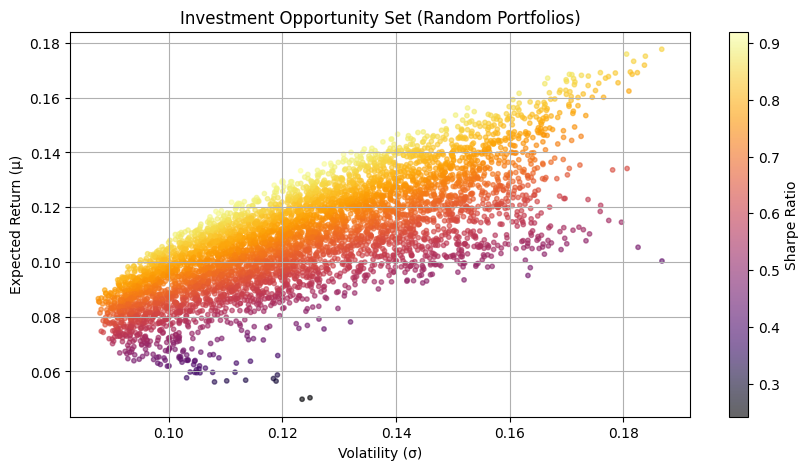

In [28]:
mu = np.array(returns.mean() * 252).reshape(-1,1)  # Expected returns
Sigma = returns.cov() * 252  # Covariance matrix
risk_free_rate = 0.02  # Risk-free rate

# 2. Portfolio optimization functions to calculate expected return/volatility/shapre-ratio
def portfolio_return(weights):
    return weights.T @ mu

def portfolio_volatility(weights):
    return np.sqrt(weights.T @ Sigma @ weights)

def portfolio_sharpe(weights):
    return (portfolio_return(weights) - risk_free_rate) / portfolio_volatility(weights)

# Scatterplot Investment Opportunity-Set
np.random.seed(42)
n_portfolios = 5000
all_weights = np.random.dirichlet(np.ones(len(mu)), size=n_portfolios)
returns_list = []
vols_list = []

for w in all_weights:
    ret = portfolio_return(w).item()
    vol = portfolio_volatility(w).item()
    returns_list.append(ret)
    vols_list.append(vol)


sharpe_list = [(r - risk_free_rate) / v for r, v in zip(returns_list, vols_list)]

plt.figure(figsize=(10,5))
plt.scatter(vols_list, returns_list, c=sharpe_list, cmap='inferno', s=10, alpha=0.6)
plt.colorbar(label='Sharpe Ratio')
plt.title('Investment Opportunity Set (Random Portfolios)')
plt.xlabel('Volatility (σ)')
plt.ylabel('Expected Return (μ)')
plt.grid(True)
plt.show()



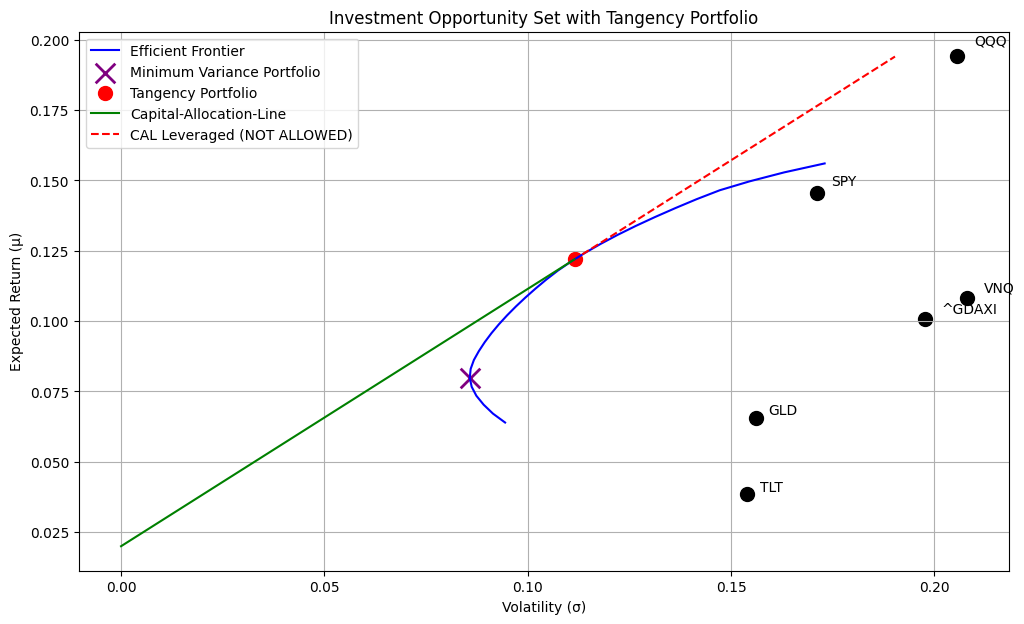

Tangency Portfolio Composition:
GLD: 14.31%
QQQ: 40.00%
SPY: 14.47%
TLT: 27.98%
VNQ: 0.00%
^GDAXI: 3.23%

Tangency Portfolio Performance:
Expected Return: 12.21% p.a.
Volatility: 11.17% p.a.
Sharpe Ratio: 0.91

Optimal Complete Portfolio (Risk Aversion = 9):
Allocation to Tangency Portfolio: 90.95%
Allocation to Risk-Free Asset: 9.05%
Expected Return: 11.29% p.a.
Volatility: 10.16% p.a.


In [29]:


# 3. Efficient Frontier Calculation
def calculate_efficient_frontier(mu, Sigma):
    target_returns = np.linspace(mu.min(), mu.max(), 50)
    efficient_weights = []
    
    for target in target_returns:
        constraints = [
            {'type': 'eq', 'fun': lambda w: np.sum(w) - 1},
            {'type': 'eq', 'fun': lambda w: portfolio_return(w) - target}
        ]
        
        result = minimize(
            portfolio_volatility,
            x0=np.ones(len(mu))/len(mu),
            bounds=[(0,0.4) for _ in range(len(mu))], # dont invest more than 50% into one asset
            constraints=constraints
        )
        
        if result.success:
            efficient_weights.append(result.x)
    
    return efficient_weights

    

efficient_weights = calculate_efficient_frontier(mu, Sigma)
efficient_returns = [portfolio_return(w).item() for w in efficient_weights]
efficient_volatilities = [portfolio_volatility(w).item() for w in efficient_weights]

# 4. Tangency Portfolio 
def find_tangency_portfolio(mu, Sigma, risk_free_rate):
    constraints = [{'type': 'eq', 'fun': lambda w: np.sum(w) - 1}]
    bounds = [(0,0.4) for _ in range(len(mu))]
    
    result = minimize(
        lambda w: -portfolio_sharpe(w),
        x0=np.ones(len(mu))/len(mu),
        bounds=bounds,
        constraints=constraints
    )
    
    return result.x if result.success else None

tangency_weights = find_tangency_portfolio(mu, Sigma, risk_free_rate)
tangency_return = portfolio_return(tangency_weights).item()
tangency_volatility = portfolio_volatility(tangency_weights).item()



plt.figure(figsize=(12,7))

# Efficient frontier
plt.plot(efficient_volatilities, efficient_returns, 'b-', label='Efficient Frontier')

# Marking Minimum Variance Portfolio
min_vol_idx = np.argmin(efficient_volatilities)
plt.scatter(efficient_volatilities[min_vol_idx], efficient_returns[min_vol_idx], 
            marker='x', s=200, c='purple', linewidths=2, label='Minimum Variance Portfolio')


asset_volatilities = np.sqrt(np.diag(Sigma))
for i, ticker in enumerate(tickers):
    plt.scatter(asset_volatilities[i], mu[i], c='k', s=100)
    plt.text(asset_volatilities[i]*1.02, mu[i]*1.02, ticker, fontsize=10)  

# Tangency portfolio
plt.scatter(tangency_volatility, tangency_return, c='r', s=100, label='Tangency Portfolio')

# Capital allocation line
x_full = np.linspace(0, max(efficient_volatilities)*1.1, 100)
y_full = risk_free_rate + (tangency_return - risk_free_rate)/tangency_volatility * x_full

# Part without leveraging portfolio
mask_lower = x_full <= tangency_volatility
plt.plot(x_full[mask_lower], y_full[mask_lower], 'g-', label='Capital-Allocation-Line')

# Part with leverage 
mask_upper = x_full >= tangency_volatility
plt.plot(x_full[mask_upper], y_full[mask_upper], 'r--', label='CAL Leveraged (NOT ALLOWED)')

plt.xlabel('Volatility (σ)')
plt.ylabel('Expected Return (μ)')
plt.title('Investment Opportunity Set with Tangency Portfolio')
plt.legend()
plt.grid(True)
plt.show()



# 6. Portfolio Composition and Performance
print("Tangency Portfolio Composition:")
for ticker, weight in zip(tickers, tangency_weights):
    print(f"{ticker}: {weight*100:.2f}%")

print(f"\nTangency Portfolio Performance:")
print(f"Expected Return: {tangency_return*100:.2f}% p.a.")
print(f"Volatility: {tangency_volatility*100:.2f}% p.a.")
print(f"Sharpe Ratio: {(tangency_return - risk_free_rate)/tangency_volatility:.2f}")

# 7. Optimal Complete Portfolio
def optimal_complete_portfolio(tangency_weights, risk_aversion):
    excess_return = tangency_return - risk_free_rate
    optimal_y = excess_return / (1*risk_aversion * tangency_volatility**2)
    optimal_y = min(optimal_y, 1.0)  # No leverage!!!!!
    
    complete_return = risk_free_rate + optimal_y * excess_return
    complete_volatility = optimal_y * tangency_volatility
    
    return optimal_y, complete_return, complete_volatility

risk_aversion = 9  # high risk aversion
y_star, complete_return, complete_volatility = optimal_complete_portfolio(tangency_weights, risk_aversion)

print(f"\nOptimal Complete Portfolio (Risk Aversion = {risk_aversion}):")
print(f"Allocation to Tangency Portfolio: {y_star*100:.2f}%")
print(f"Allocation to Risk-Free Asset: {(1-y_star)*100:.2f}%")
print(f"Expected Return: {complete_return*100:.2f}% p.a.")
print(f"Volatility: {complete_volatility*100:.2f}% p.a.")

---
---
## 3) Tangency Portfolio vs. Optimal Complete Portfolio

The **Tangency Portfolio** is the portfolio on the efficient frontier that maximizes the **Sharpe Ratio**:

$$
\text{Sharpe Ratio} = \frac{\mathbb{E}[R_p] - R_f}{\sigma_p}
$$

It represents the best trade-off between risk and return across risky assets. Visually, it is the point where the **Capital Allocation Line (CAL)** is a tangent to the **efficient frontier**.

---

### Why are the assets distributed this way?

The optimal risky portfolio allocation (Tangency Portfolio) is the result of **mean-variance optimization** under constraints (in our case max 40% per asset, no short-selling). The current composition is:

- **QQQ (Nasdaq 100)**: 40.0%  
- **TLT (Long-term U.S. Bonds)**: 28.0%  
- **SPY (S&P 500)**: 14.5%  
- **GLD (Gold)**: 14.3%  
- **^GDAXI (German Index)**: 3.2%  
- **VNQ (REITs)**: 0.0%

**Interpretation**:
- **QQQ** reaches the **maximum cap of 40%**, showing that the optimizer would put even more weight based on its return and Sharpe ratio—but is **capped to limit concentration risk**.
- This constraint is **important** to avoid overexposure to a single sector or market (in our case U.S. tech), which could make the portfolio super sensitive to sector-specific shocks.
- **TLT** complements equities as a hedge (negatively correlated), reducing portfolio volatility.
- **VNQ** and **^GDAXI** play minor roles due to either correlation redundancy or suboptimal risk-return profiles.
- **GLD** is included as a non-correlated diversifier.

---

### What is the Optimal Complete Portfolio?

The **Optimal Complete Portfolio** combines the tangency portfolio with the **risk-free asset**, it depends on the investor’s **risk aversion (A)**.

The optimal share invested in the tangency portfolio is calculated as:

$$
y^* = \frac{\mathbb{E}[R_p] - R_f}{A \cdot \sigma_p^2}
$$

Given a (high) risk aversion of $A = 9$, the optimal composition is:

- **90.95%** Tangency Portfolio  
- **9.05%** Risk-Free Asset  

This portfolio lies on the **Capital Allocation Line (CAL)** and delivers a personalized mix of return and risk. We are very risk-averse.

---

### Summary & Interpretation

- The **Tangency Portfolio** provides the most efficient mix of risky assets.
- The **Optimal Complete Portfolio** adapts this mix considering our personal risk tolerance.
- In this case, the **expected return is 11.29%** with **volatility of 10.16%**, resulting in a **Sharpe Ratio of 0.91**.
- The pie chart clearly shows a **concentrated exposure to tech (QQQ)** and **bonds (TLT)**, while still maintaining diversification through **gold** and **international equities**.
- **Capping asset weights** improves robustness by avoiding excessive focus on a single asset (Nasdaq100ETF).


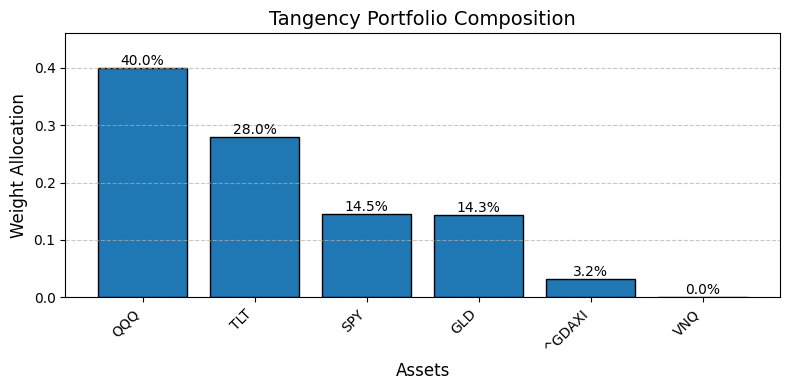

In [11]:
# Portfolio Composition Plot
plt.figure(figsize=(8, 4))

# Sort assets by weight in a descending order
sorted_indices = np.argsort(tangency_weights)[::-1]
sorted_tickers = [tickers[i] for i in sorted_indices]
sorted_weights = [tangency_weights[i] for i in sorted_indices]

# Bar plot
bars = plt.bar(sorted_tickers, sorted_weights, edgecolor='black')


for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height*100:.1f}%',
             ha='center', va='bottom')


plt.title('Tangency Portfolio Composition', fontsize=14)
plt.xlabel('Assets', fontsize=12)
plt.ylabel('Weight Allocation', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.ylim(0, min(0.5, max(tangency_weights)*1.15)) 
plt.grid(axis='y', linestyle='--', alpha=0.7)


plt.axhline(0, color='black', linewidth=0.5)

plt.tight_layout()
plt.show()

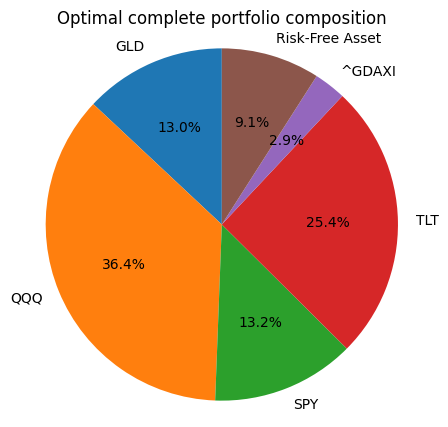

In [12]:
labels = list(tickers) + ['Risk-Free Asset']
weights = list(y_star * tangency_weights) + [1 - y_star]

# Filter very small assets with weight > 0.5%
labels, weights = zip(*[(l, w) for l, w in zip(labels, weights) if w > 0.005])

plt.figure(figsize=(5, 5))
plt.pie(weights, labels=labels, autopct='%1.1f%%', startangle=90)
plt.title('Optimal complete portfolio composition')
plt.axis('equal')
plt.show()

---
---
## 4) Risk Decomposition Using Linear Regression

To understand the **source of risk and return** in a portfolio, we decompose its performance into **systematic (market-related)** and **idiosyncratic (unique)** components.

This is done using **linear regression**, where the portfolio's excess return is regressed on the market's excess return:

$$
R_p - R_f = \alpha + \beta (R_m - R_f) + \epsilon
$$

- $R_p$: Portfolio return  
- $R_f$: Risk-free rate  
- $R_m$: Market return  
- $\alpha$: Idiosyncratic (non-market) return  
- $\beta$: Sensitivity of the portfolio to the market (systematic risk)  
- $\epsilon$: Residual (unexplained) return

We can also decompose the **portfolio’s total risk** (volatility) as:

$$
\sigma_p^2 = (\beta \cdot \sigma_m)^2 + \sigma_\epsilon^2
$$

- $\sigma_p$: Total portfolio standard deviation  
- $\sigma_m$: Market standard deviation  
- $\sigma_\epsilon$: Idiosyncratic risk (residual volatility)

This allows us to quantify how much of the portfolio's behavior is **explained by the market**, and how much is **special to the portfolio strategy**.


In [13]:
import statsmodels.api as sm
import numpy as np
import pandas as pd

def perform_risk_analysis(portfolio_weights, returns, risk_free_rate=0.02, market_proxy='SPY'):
    """Decompose portfolio performance into systematic and idiosyncratic components using OLS."""
    
    
    portfolio_returns = (returns * portfolio_weights).sum(axis=1)

    
    market_excess = returns_market[market_proxy] - risk_free_rate / 252
    portfolio_excess = portfolio_returns - risk_free_rate / 252

    
    common_index = portfolio_excess.index.intersection(market_excess.index)
    portfolio_excess = portfolio_excess.loc[common_index]
    market_excess = market_excess.loc[common_index]

    # Run OLS
    X = sm.add_constant(market_excess)
    model = sm.OLS(portfolio_excess, X).fit()

    print(model.summary())

    # Coefficents
    beta = model.params.iloc[1]
    alpha = model.params.iloc[0]

    # Calculate Return Composition
    systematic_return = beta * market_excess.mean() * 252  + risk_free_rate # systematic_excess_return + risk_free_rate = systematic_return
    idiosyncratic_return = alpha * 252
    total_return = systematic_return + idiosyncratic_return 

    # Calculate Risk Composition
    residuals = model.resid
    systematic_risk = beta * market_excess.std() * np.sqrt(252)
    idiosyncratic_risk = residuals.std() * np.sqrt(252)
    total_risk = np.sqrt(systematic_risk**2 + idiosyncratic_risk**2)

    return {
        'Total Return': total_return,
        'Systematic Return (β)': systematic_return,
        'Idiosyncratic Return (α)': idiosyncratic_return,
        'Total Risk': total_risk,
        'Systematic Risk (βσₘ)': systematic_risk,
        'Idiosyncratic Risk (σₑ)': idiosyncratic_risk,
        'Beta (β)': beta,
        'Alpha (α)': alpha * 252,
        'R-squared': model.rsquared
    }


risk_table = perform_risk_analysis(tangency_weights, returns)

print("Risk Decomposition for Tangency Portfolio:")
pd.DataFrame.from_dict(risk_table, orient='index', columns=['Value'])



                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.680
Model:                            OLS   Adj. R-squared:                  0.680
Method:                 Least Squares   F-statistic:                     7866.
Date:                Sun, 25 May 2025   Prob (F-statistic):               0.00
Time:                        17:27:44   Log-Likelihood:                 15226.
No. Observations:                3707   AIC:                        -3.045e+04
Df Residuals:                    3705   BIC:                        -3.043e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0001   6.55e-05      2.209      0.0

,Value
Total Return,0.122125
Systematic Return (β),0.085688
Idiosyncratic Return (α),0.036436
Total Risk,0.111698
Systematic Risk (βσₘ),0.092095
Idiosyncratic Risk (σₑ),0.063205
Beta (β),0.540129
Alpha (α),0.036436
R-squared,0.679805


---
---
## OLS Regression & Risk Decomposition of the Tangency Portfolio

To better understand where the performance of our tangency portfolio comes from, we decompose the return and risk using **linear regression** against a benchmark (S&P500).

#### OLS Regression Output:

- **Beta (ß) = 0.540**  
  → The portfolio reacts moderately to market movements. A 1% change in the market leads to a 0.54% change in the portfolio.

- **Alpha (α) = 0.0364**  
  → The portfolio generates a **positive idiosyncratic return** of 3.64% that is not explained by market risk.

- **R² = 0.680**  
  → 68% of the portfolio's excess return variability is explained by market movements, while 32% stems from specific portfolio characteristics (non-systematic risk).

#### Significance of Coefficients:

- Both **β** and **α** are **statistically significant** (p-values < 0.05).  
  → This confirms that the regression model captures both systematic and idiosyncratic return components.

---

#### Return Decomposition:

- **Total Return**: 12.21% p.a.  
- **Systematic Return (β × E[R_m - R_f])**: 8.57% p.a.  
- **Idiosyncratic Return (α)**: 3.64% p.a.

#### Risk Decomposition:

- **Total Risk (σₚ)**: 11.17% p.a.  
- **Systematic Risk (β × σₘ)**: 9.02% p.a.  
- **Idiosyncratic Risk (σ_ε)**: 6.32% p.a.

---

#### Interpretation:

The portfolio shows **moderate exposure to market risk**, but also **delivers additional return** through our selected assets
The **statistically significant alpha** confirms that the portfolio outperforms more than what would be expected from its beta alone.
This decomposition comfirms the value of our investment-project approach and shows that the our portfolio offers **both diversification and outperformance potential**.


---
---
## 5) Expected vs. Realized Performance of the Tangency Portfolio

Now we compare the **expected performance** (on the training sample) with the **realized performance** (on the test sample).

#### Method:
- Train/Test split: 70 % / 30 % 
- Expected return and volatility formulas are:

$$
\mu_p = \sum_{i=1}^{n} w_i \cdot \mu_i, \quad
\sigma_p = \sqrt{\mathbf{w}^T \Sigma \mathbf{w}}
$$


In [16]:

returns_period = returns.loc[start_date:end_date]

 # 70 % Train, 30 % Test
total_days = len(returns_period)
train_days = int(0.7 * total_days)


returns_train = returns_period.iloc[:train_days]
returns_test = returns_period.iloc[train_days:]

# excepted perf
mu_train = returns_train.mean() * 252
sigma_train = returns_train.cov() * 252

expected_perf = np.sum(mu_train * tangency_weights)
expected_risk = np.sqrt(tangency_weights.T @ sigma_train @ tangency_weights)

# Realized perf
daily_realized = returns_test * tangency_weights
portfolio_path = daily_realized.sum(axis=1)

realized_perf = portfolio_path.mean() * 252
realized_risk = portfolio_path.std() * np.sqrt(252)


print(f"Expected Return: {expected_perf:.4f}, Expected Volatility: {expected_risk:.4f}")
print(f"Realized Return: {realized_perf:.4f}, Realized Volatility: {realized_risk:.4f}")


Expected Return: 0.1376, Expected Volatility: 0.1000
Realized Return: 0.0861, Realized Volatility: 0.1352


### Interpretation of Out-of-Sample Results

- **Expected Return**: 13.76% p.a. vs. **Realized Return**: 8.61% p.a.  
- **Expected Volatility**: 10.00% p.a. vs. **Realized Volatility**: 13.52% p.a.

The realized performance is significantly different from our expectations:

- The return is **lower than expected**, indicating the model may have overestimated future profitability.
- The realized risk is **higher**, suggesting stronger market fluctuations or underestimation of variance.

This shows the importance of **out-of-sample testing**:

- Even if in-sample performance looks strong, **future outcomes are uncertain**.
- Differences can result from **changing market conditions**, **parameter estimation errors**, or **overfitting** to old data.
